In [1]:
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt

import sys
sys.path.append("../utils/")
import format_stim_data
import scipy.io
import os

In [2]:
''' set paths '''
save_folder = f"../figures/antidromic_hpc_to_lhy/"
data_folder = f"../data/antidromic_stim/"

if os.path.isdir(save_folder):
    print('save folder exists')
else:
    os.mkdir(save_folder)

save folder exists


In [3]:
''' get the bird and session info '''
# all bird names
bird_ids = os.listdir(data_folder)

# example bird
ex_id = 0
bird_id = bird_ids[ex_id]

# session IDs
sessions = os.listdir(f"{data_folder}{bird_id}")
ex_session = sessions[5]

In [4]:
''' load and format the data '''
voltage, timestamps = format_stim_data.load_stim(data_folder, bird_id, ex_session)

dt=0.0001
v, t = format_stim_data.resample(voltage, timestamps, dt=dt)

In [5]:
n_obs = timestamps.shape[0]
n_sec = np.max(timestamps)
n_obs / n_sec

499.89313982987096

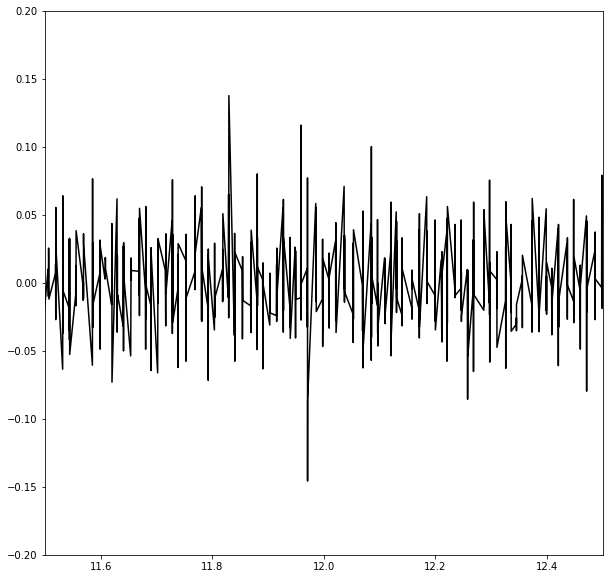

In [19]:
t_max = np.max(timestamps)

f, ax = plt.subplots(1, 1, figsize=(10,10))

ax.plot(timestamps, voltage, 'k')

# ax.plot(t, v, 'k')
ax.set_xlim([11.5, 12.5])
ax.set_ylim([-0.2, 0.2])

plt.show()
plt.show()

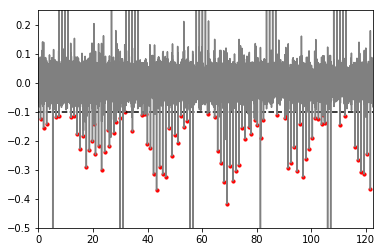

In [7]:
from scipy.signal import find_peaks

min_thresh=0.1
max_thresh=1
t_max = np.max(timestamps)

# find the stimulation artifact
stim_idx, _ = find_peaks(-v, 
                         height=[min_thresh, max_thresh],
                         distance=5000
                        )

# sanity check
f, ax = plt.subplots(1, 1)
ax.plot(t, v, 'gray')
xlim = ax.get_xlim()

ax.hlines(-min_thresh, xlim[0], xlim[1], 
          colors='k', linestyles='dashed')
ax.scatter(t[stim_idx], v[stim_idx], c='r', s=10)

ax.set_xlim([0, t_max])
ax.set_ylim([-0.5, 0.25])

plt.show()

In [70]:
n_stim = stim_idx.shape[0]
np.max(timestamps) / n_stim

1.4446146258823265

In [71]:
''' plot each stimulation trial '''
before_t = 0.01 # 10ms
after_t = 0.02 # 20ms
b_idx = np.round(before_t / dt).astype(int)
a_idx = np.round(after_t / dt).astype(int)

n_bins = b_idx + a_idx
n_stim = stim_idx.shape[0]

stim_events = np.zeros((n_stim, n_bins))
for i, s_idx in enumerate(stim_idx):
    start = s_idx - b_idx
    end = s_idx + a_idx    
    stim_events[i] = v[start:end]

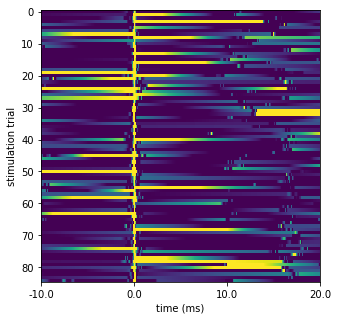

In [72]:
f, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(-stim_events, clim=[0, 0.1], 
          aspect='auto', cmap='viridis')
ax.set_xticks(np.arange(0, n_bins+5, 100))
ax.set_xticklabels(np.arange(-before_t*1000, (after_t*1000)+5, 10)) # ms

ax.set_ylabel('stimulation trial')
ax.set_xlabel('time (ms)')

f.savefig(f'{save_folder}responses.png', dpi=600, bbox_inches='tight')
plt.show()

In [33]:
n_bins

300